# Pricing American Put Options Using Binomial Trees

An **American option** is the right, but not the obligation, to buy (call option) or sell (put option) an underlying asset at a specified **strike price** on or before a **specified date**. 

It is never optimal to exercise an American call option early when the underlying is a non-dividend-paying stock, and so pricing such an option is equivalent to pricing a European option with the same strike price and maturity. Therefore, we consider here the problem of pricing American put options using binomial trees, where the underlying is a non-dividend-paying stock.

Let $S_0$ be the current stock price and $T$ be the time (in years) till maturity of the option. Let $N$ be the number of time steps. Then, each time step is of length $\Delta t = \frac{T}{N}$. Let $S_n$, where $n = 1, 2, ..., N$, denote the stock price after $n$ steps. In the binomial model, we assume that after each step, the stock price either goes up so that $S_n = uS_{n - 1}$, or down so that $S_n = dS_{n - 1}$, where:

$$ u = e^{\sigma \sqrt{\Delta t}} \text{ and } d = \frac{1}{u} = e^{-\sigma \sqrt{\Delta t}} $$

Here, $\sigma$ is the volatility of the stock price. 

We first calculate the volatility of the stock as follows:

In [1]:
import math
import numpy as np
import pandas as pd
import yfinance as yf
from pylab import plt
import pandas_datareader.data as web
import datetime as dt

In [2]:
'''
Calculating the daily log returns of a stock.
ticker: a Ticker object
Returns an ndarray containing the daily log returns of the stock.
'''

def calc_daily_log_return(ticker):
    
    # The history() method of a Ticker object returns a Pandas DataFrame which is converted to an ndarray by the method to_numpy()
    close_history = ticker.history(period="2y")["Close"].to_numpy()
    
    daily_log_return = np.log(close_history[1:]/close_history[:-1])

    return daily_log_return

In [3]:
'''
Calculating the volatility of the stock price.
Takes as input a Ticker object.
'''

def volatility(ticker):
    
    daily_ret = calc_daily_log_return(ticker)
    sigma = np.std(daily_ret, ddof=1) * np.sqrt(252) # np.std(daily_ret) gives the daily volatility, multiply by sqrt(252) to obtain the annual volatility

    return sigma

The riskless short rate $r$ is approximated by Treasury-bill yields. We obtain them based on the time horizon. For instance, if the maturity is 3 months from now, we use the yield of the three-month T-bill. If we obtain the yield as $r_y$ then, assuming continuous compounding, the riskless rate is given by

$$ r = \ln(1 + r_y) $$

In [4]:
'''
This function takes t, the time interval between today and maturity, in years.
'''

def calc_r(t):
    start = dt.datetime(2026,1,1)  # start date, irrelevant here but required as an argument in the DataReader function
    end = dt.datetime.today()
    r_y = 0

    # 3 month horizon, use 3-month T-bill
    if t <= 0.25:
        r_y = web.DataReader("DTB3", "fred", start, end).iloc[-1,0] / 100 # rates are returned in percentage and so division by 100
    
    # 3 to 9 month horizon, use 6-month T-bill
    elif t <= 0.5:
        r_y = web.DataReader("DTB6", "fred", start, end).iloc[-1,0] / 100
    
    # for longer time horizons, use 1-year T-bill
    else:
        r_y = web.DataReader("DTB1YR", "fred", start, end).iloc[-1,0] / 100

    r = np.log(1 + r_y)  # this is the annual riskless rate

    return r

The risk-neutral probability $p$ has the following formula:

$$ p = \frac{e^{r \Delta t} - d}{u - d} $$

In [5]:
'''
Calculating the risk-neutral probability p
r: risk-free rate
dt: length of each time step (in years)
u: calculated by calc_u
'''

def calc_p(r, dt, u):
    d = 1 / u
    return (np.exp(r * dt) - d) / (u - d)

We can now calculate the binomial tree for simulating stock prices. $S[i, t]$ denotes the stock price in the $i$-th state, after $t$ time periods. We start with `S[0,0]` as the current stock price. 

In case of an upward movement, $ S_t = uS_{t - 1} $, while for a downward movement, $ S_t = dS_{t - 1}. $

In the implementation below, $S[i, t + 1]$ denotes the stock price after an upward movement of the price at $S[i, t]$: 

$$S[i, t + 1] = u \cdot S[i, t]$$ 

while $S[i + 1, t + 1]$ denotes the stock price after a downward movement:

$$S[i + 1, t + 1] = d \cdot S[i, t]$$

In [6]:
'''
Calculating the binomial tree for simulating stock prices.
S0: current stock price
u: calculated by calc_u
N: number of periods
'''

def stock_bt(S0, u, N):
    d = 1 / u
    S = np.zeros((N + 1, N + 1))
    S[0, 0] = S0

    for i in range(0, N + 1):
        for t in range(i, N + 1):
            if i == t == 0:
                continue
            if i == t:
                S[i, t] = d * S[i - 1, t - 1]
            else:
                S[i, t] = u * S[i, t - 1]

    return S   

For example, consider a stock currently at \\$50, with $u = 1.2$ and two time periods in the binomial tree.

In [7]:
S0 = 50
u = 1.2
N = 2

np.set_printoptions(formatter={'float':
lambda x: '%6.2f' % x})

S = stock_bt(S0, u, N)
print(S)

[[ 50.00  60.00  72.00]
 [  0.00  41.67  50.00]
 [  0.00   0.00  34.72]]


We can visualize this as follows:

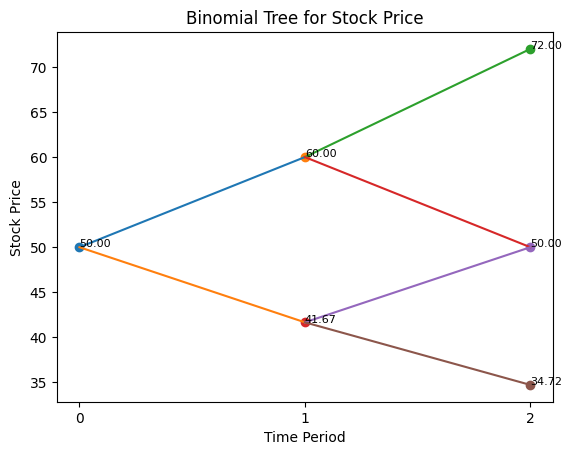

In [8]:
'''
Visualizing the stock price lattice.
S: ndarray containing the stock price lattice
'''

def plot_tree(S):
    rows, cols = S.shape

    for r in range(rows):
        for t in range(r, cols):            
                plt.scatter(t, S[r, t])  # plots a single point
                plt.text(t, S[r, t], f"{S[r,t]:.2f}", fontsize=8)  # adds text at the point                

                if t + 1 < cols:  # ensures we are not at the last column                    
                    plt.plot([t, t + 1], [S[r, t], S[r, t + 1]])  # plots the up line
                    
                    if r + 1 < rows: # checks if the row below exists
                        plt.plot([t, t + 1], [S[r, t], S[r + 1, t + 1]])  # plots the down line

    plt.xlabel("Time Period")
    plt.xticks(range(cols))
    plt.ylabel("Stock Price")
    plt.title("Binomial Tree for Stock Price")
    plt.show()

plot_tree(S)

To calculate the binomial tree for the option price, we first calculate the option price at maturity. Let $S[i, t]$ denote the stock price in the $i$-th state after $t$ periods. Then, the last column contains possible stock prices at maturity and the option price at maturity is given by $\max(0, K - S_T)$. We then work backwards in the lattice. At each time step $t = 0, 1, ..., N - 1$, the expected option price is given by:

$$ f_{i, t} = e^{-r\Delta t} [pf_{i, t + 1} + (1 - p)f_{i + 1, t + 1}] $$

where $f_{i, t}$ denotes the option price in state $i$ and after $t$ periods, $r$ denotes the riskless rate, $p$ denotes the risk-neutral probability of the stock going up, and $\Delta t$ denotes the length of one time period (in years). However, since we are pricing an American put option, we can also exercise the option at time $t$, in which case the option value is $f'_{i, t} = \max(0, K - S_{i, t})$. The option value at $(i, t)$ is given by $\max(f_{i, t}, f'_{i, t})$.

We also return a `set` containing the indices of all the positions in the lattice where early exercise is optimal. 

In [9]:
'''
Calculating the binomial tree for simulating the option price. 
S: ndarray representing the binomial tree for stock price, calculated using function stock_bt()
K: strike price
p: risk-neutral probability of the stock going up
df: discount factor, exp(-r * dt)
'''

def option_bt(S, K, p, df):
    O = np.zeros_like(S)
    early_optimal = set()
    rows, cols = S.shape
    T = cols - 1  # last time period
    
    # valuing the option at time T (maturity)
    for row in range(rows):
        O[row, T] = max(K - S[row, T], 0)

    # working backwards in the lattice
    t = T - 1
    while t >= 0:
        for row in range(t + 1):
            exp_value = df * (p * O[row, t + 1] + (1 - p) * O[row + 1, t + 1])
            early_exercise = max(0, K - S[row, t])
            O[row, t] = max(exp_value, early_exercise)

            if early_exercise > exp_value:
                early_optimal.add((row, t))
        t -= 1
    
    return O, early_optimal

Consider again the example we used for calculating the binomial tree for a stock. Suppose the strike price is $ \$ 52$, $p = 0.6282$, and the discount factor is $0.9512$.

In [10]:
K = 52
p = 0.6282
df = 0.9512

O, early_optimal = option_bt(S, K, p, df)
print(O)

[[  4.08   0.71   0.00]
 [  0.00  10.33   2.00]
 [  0.00   0.00  17.28]]


To visualize this, we use the following function:

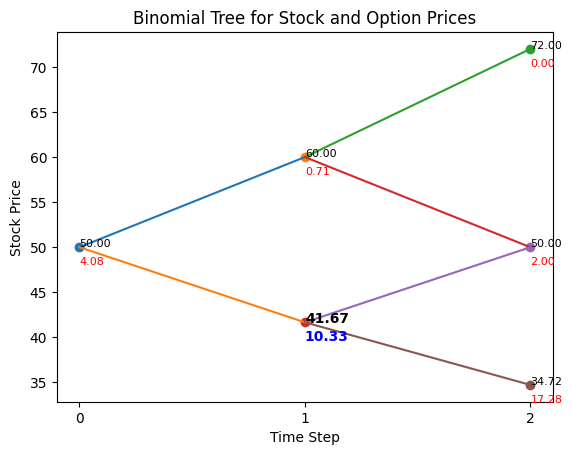

In [11]:
'''
Visualizing the lattice with both stock and option prices.
S: stock price lattice
O: option price lattice
early_op: set with all the nodes where early exercise is optimal
'''

def plot_tree(S, O, early_op):
    rows, cols = S.shape

    for r in range(rows):
        for t in range(r, cols):            
                plt.scatter(t, S[r, t])  # plots a single point
                
                # if early exercise is optimal for this node, we emphasize it
                if (r, t) in early_op:  
                    plt.text(t, S[r, t], f"{S[r,t]:.2f}", fontsize=10, fontweight="bold")  # adds stock price at the node
                    plt.text(t, S[r, t] - 2, f"{O[r,t]:.2f}", fontsize=10, color="blue", fontweight="bold")  # adds option price at the node
                
                else:
                    plt.text(t, S[r, t], f"{S[r,t]:.2f}", fontsize=8)
                    plt.text(t, S[r, t] - 2, f"{O[r,t]:.2f}", fontsize=8, color="red")           
                

                if t + 1 < cols:  # ensures we are not at the last column                    
                    plt.plot([t, t+1], [S[r,t], S[r,t+1]])  # plots a line
                    
                    if r+1 < rows: # checks if the row below exists
                        plt.plot([t, t+1], [S[r,t], S[r+1,t+1]])

    plt.xlabel("Time Step")
    plt.xticks(range(cols))
    plt.ylabel("Stock Price")
    plt.title("Binomial Tree for Stock and Option Prices")
    plt.show()

plot_tree(S, O, early_optimal)

In [12]:
'''
Pricing an American put option.
ticker_symb: string representing a ticker symbol like "AAPL"
K: strike price
T: time (in years) till maturity
N: number of periods
'''

def price_am_put(ticker_symb, K, T, N):
    ticker = yf.Ticker(ticker_symb)

    sigma = volatility(ticker)
    dt = T / N  # length of each period
    r = calc_r(T)  # riskless rate

    S0 = ticker.history(period="5d")["Close"].iloc[-1]
    u = np.exp(sigma * np.sqrt(dt))

    S = stock_bt(S0, u, N)  # stock binomial tree

    p = calc_p(r, dt, u)
    df = np.exp(-r * dt)

    O = option_bt(S, K, p, df)[0]

    return O

For example, the binomial tree for an American put option on one share of the Apple stock with strike price \\$280 and maturity after one year, using 50 time periods, is given by:

In [13]:
O = price_am_put("AAPL", 280, 1, 50)
print(O)
print("Option price: " + str(O[0, 0]))

[[ 36.65  31.15  26.08 ...   0.00   0.00   0.00]
 [  0.00  42.17  36.22 ...   0.00   0.00   0.00]
 [  0.00   0.00  48.13 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ... 241.73 240.17 238.55]
 [  0.00   0.00   0.00 ...   0.00 243.23 241.73]
 [  0.00   0.00   0.00 ...   0.00   0.00 244.67]]
Option price: 36.64929930569683
